# Analyse multidimensionnelle des trajectoires de soins pour le jeu de données `multidimensional_data`

Ce notebook présente l'application du package `trajectoryclusteringanalysis` sur un jeu de données de traitements d'un cancer exprimé en mois.

1. Configuration de l'environnement et imports
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Décomposition par l'algorithme SWoTTeD
5. Clustering sur les intensités des phénotypes

## 1. Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


## 2. Chargement et préparation des données

In [2]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [4]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [5]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


## 3. Initialisation du modèle TCA

In [6]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


In [7]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


Patient utilise pour la visualisation: 23


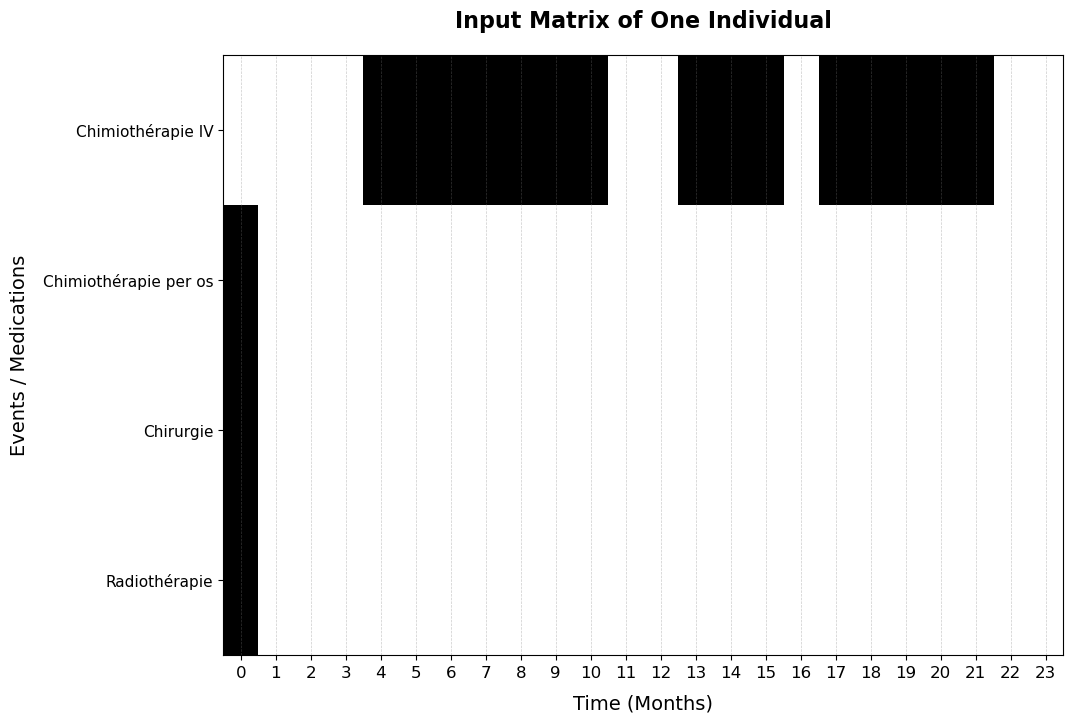

     PATIENT_ID                  EVENT  TIME
561          23              Chirurgie     0
562          23  Chimiothérapie per os     0
563          23          Radiothérapie     0
564          23          Radiothérapie     0
565          23          Radiothérapie     0
566          23          Radiothérapie     0
567          23      Chimiothérapie IV     4
568          23      Chimiothérapie IV     5
569          23      Chimiothérapie IV     5
570          23      Chimiothérapie IV     6
571          23      Chimiothérapie IV     7
572          23      Chimiothérapie IV     7
573          23      Chimiothérapie IV     8
574          23      Chimiothérapie IV     8
575          23      Chimiothérapie IV     9
576          23      Chimiothérapie IV    10
577          23      Chimiothérapie IV    13
578          23      Chimiothérapie IV    13
579          23      Chimiothérapie IV    14
580          23      Chimiothérapie IV    15
581          23      Chimiothérapie IV    17
582       

In [8]:
patient_index = int(patients_with_all_events[1])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit='Months')

print(df[df['PATIENT_ID'] == 23])

## 4. Décomposition du jeu de données à l'aide de l'algorithme SWOTTED

In [9]:
# Hyperparametres de la demo
reg_term_ns = 0.5
reg_term_s = 0.5
metric = 'Bernoulli'
learning_rate = 1e-3
n_epochs = 200  # 30 pour demo rapide, 100+ pour entrainement plus stable

ranks = [2, 3, 4]
windows = [2, 3, 4]

SWOTTED pour window=2, rank=2

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec

c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 24     | n/a

...

`Trainer.fit` stopped: `max_epochs=200` reached.


SWOTTED pour window=4, rank=4


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 64     | n/a   | n/a  
--------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


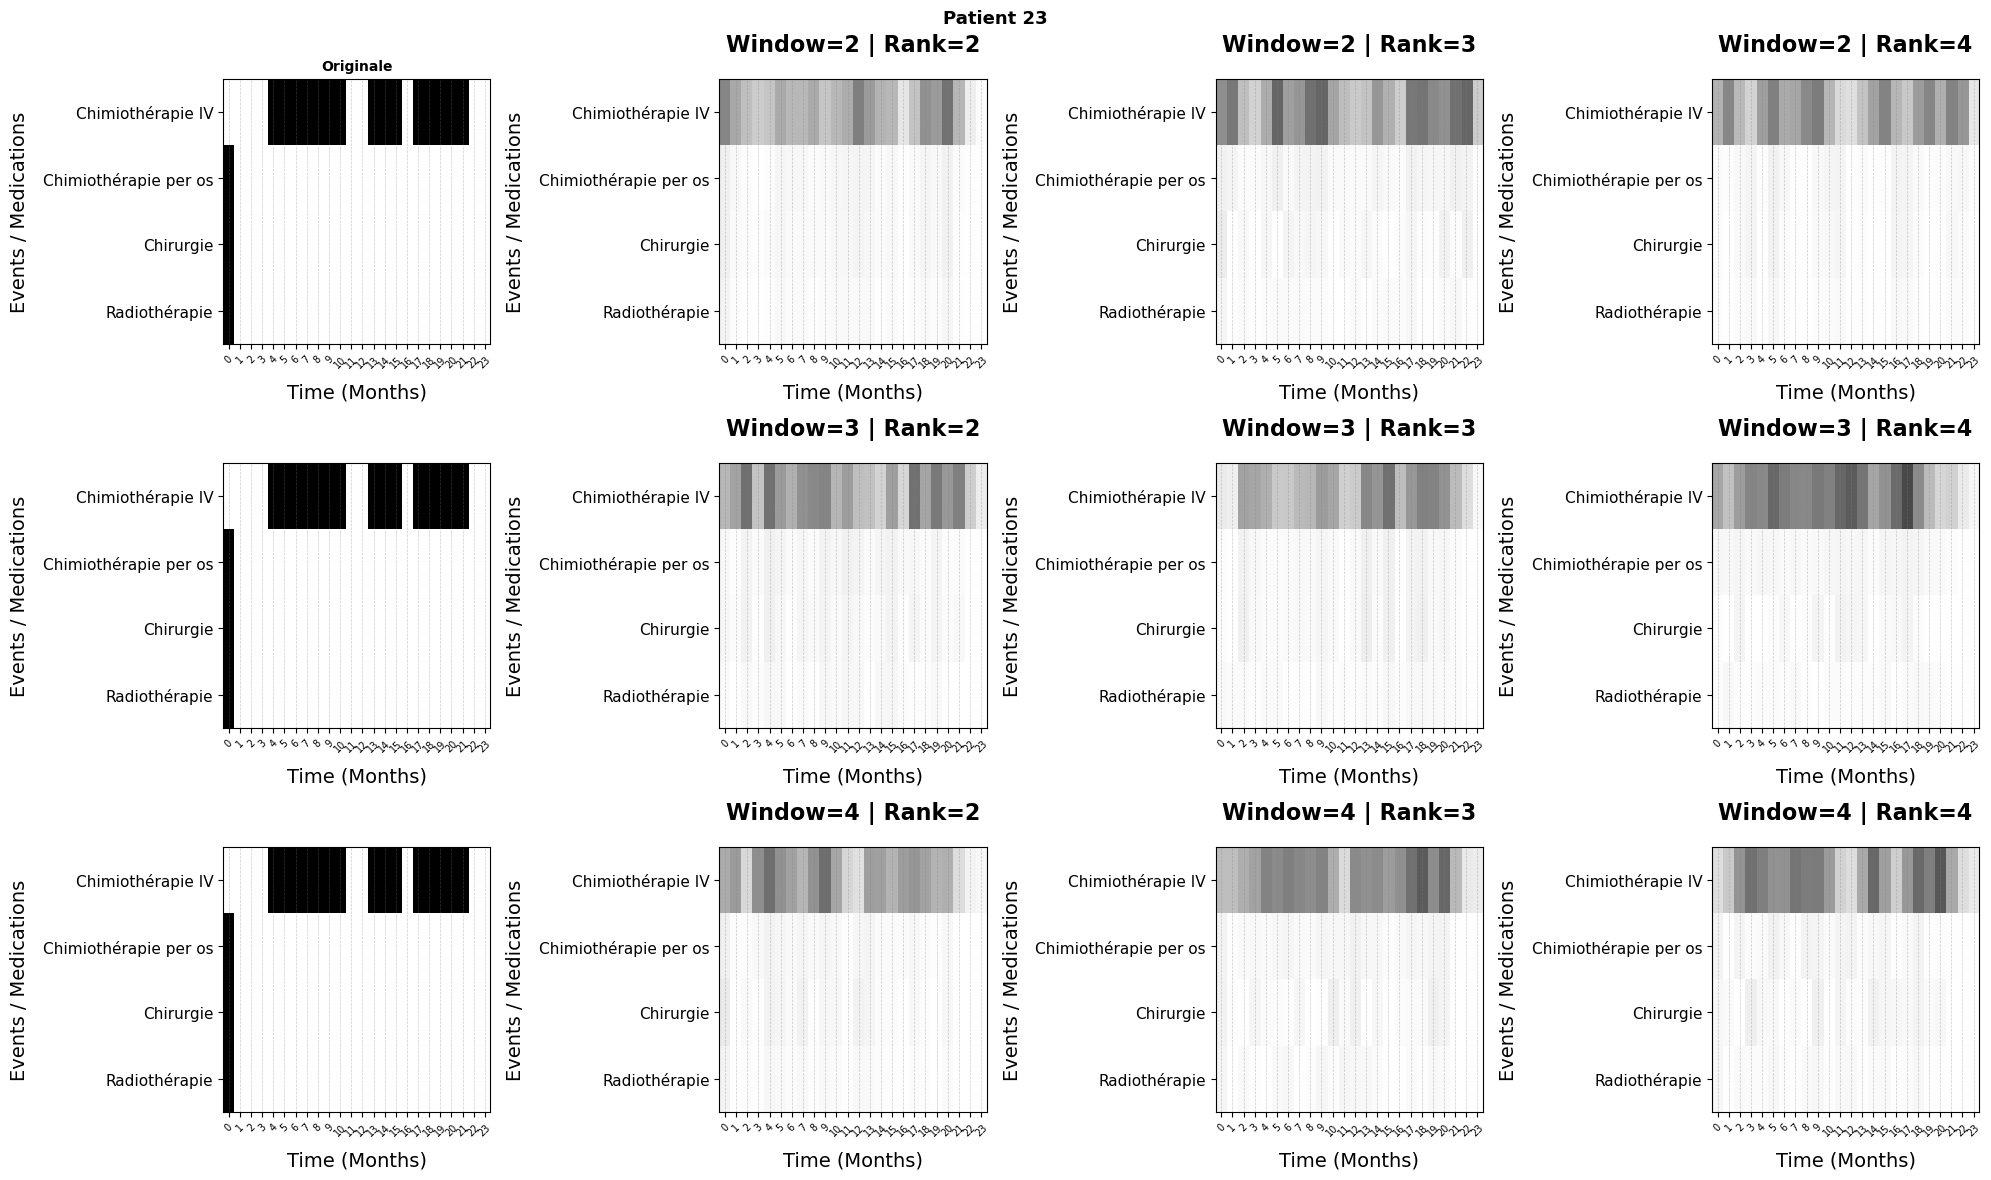

In [10]:
# SWOTTED sur plusieurs configurations de rangs et fenêtres :
models = {}
n_rows = len(windows)
n_cols = len(ranks) + 1  # col 0 = matrice originale

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for row_idx, tw in enumerate(windows):
    # Colonne 0 : matrice originale
    plot_input_matrix(tensor, id=patient_index, labels=noms_events,
                      time_unit='Months', ax=axes[row_idx][0])
    axes[row_idx][0].set_title("Originale" if row_idx == 0 else "")
    axes[row_idx][0].tick_params(axis='x', rotation=45, labelsize=7)
    if row_idx == 0:
        axes[row_idx][0].set_title("Originale", fontsize=10, fontweight='bold')

    for col_idx, rank in enumerate(ranks):
        print(f"SWOTTED pour window={tw}, rank={rank}")
        tca.analyzer.fit_swotted_decomposition(
            tensor, rank=rank, time_window_length=tw,
            reg_term_ns=reg_term_ns, reg_term_s=reg_term_s,
            metric=metric, learning_rate=learning_rate, n_epochs=n_epochs
        )
        models[(rank, tw)] = (tca.analyzer.model, tca.analyzer.W)

        X_pred = tca.analyzer.compute_reconstruction()

        # Plot
        ax = axes[row_idx][col_idx + 1]
        plot_reconstructed_matrix(X_pred, id=patient_index, labels=noms_events,
                                  title=f"Window={tw} | Rank={rank}",
                                  time_unit='Months', ax=ax)
        ax.tick_params(axis='x', rotation=45, labelsize=7)

fig.suptitle(f"Patient {patient_index}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Decomposed into 1336 pathways with rank 3 and time window length 2
FIT metric for the entire dataset: 0.1477
success_rate :0.08274692389450278


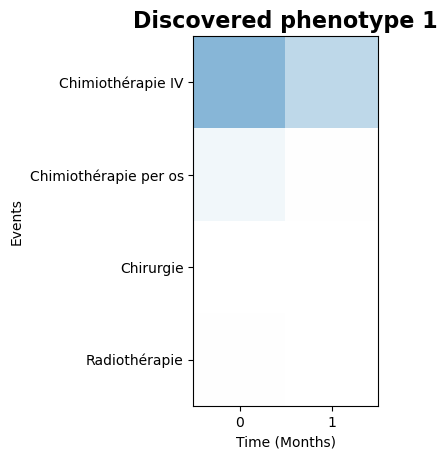

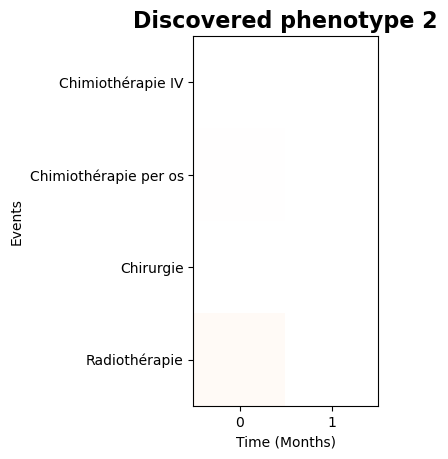

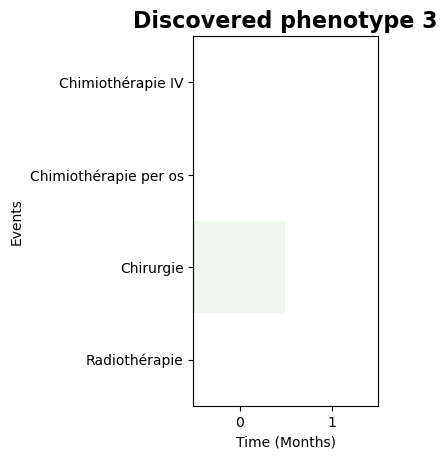

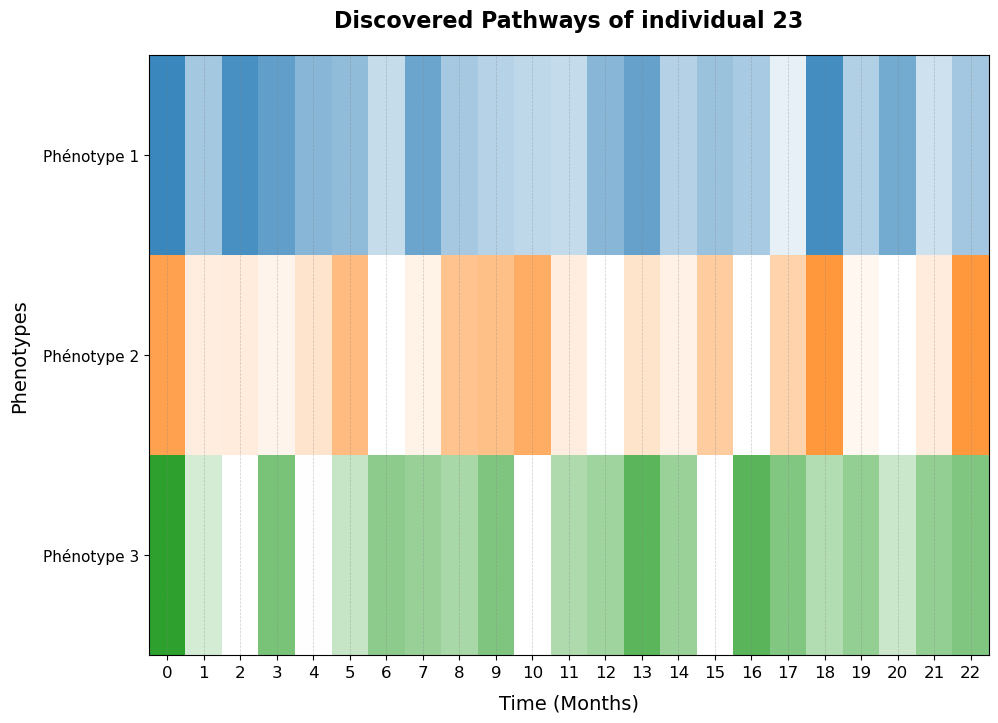

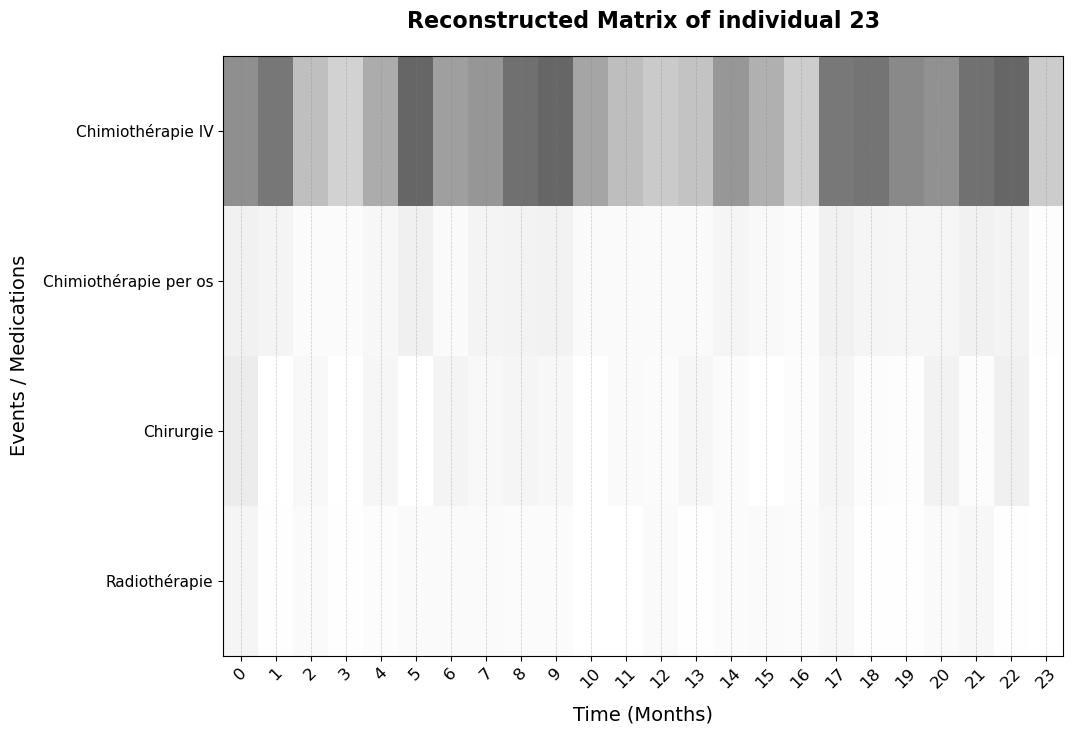

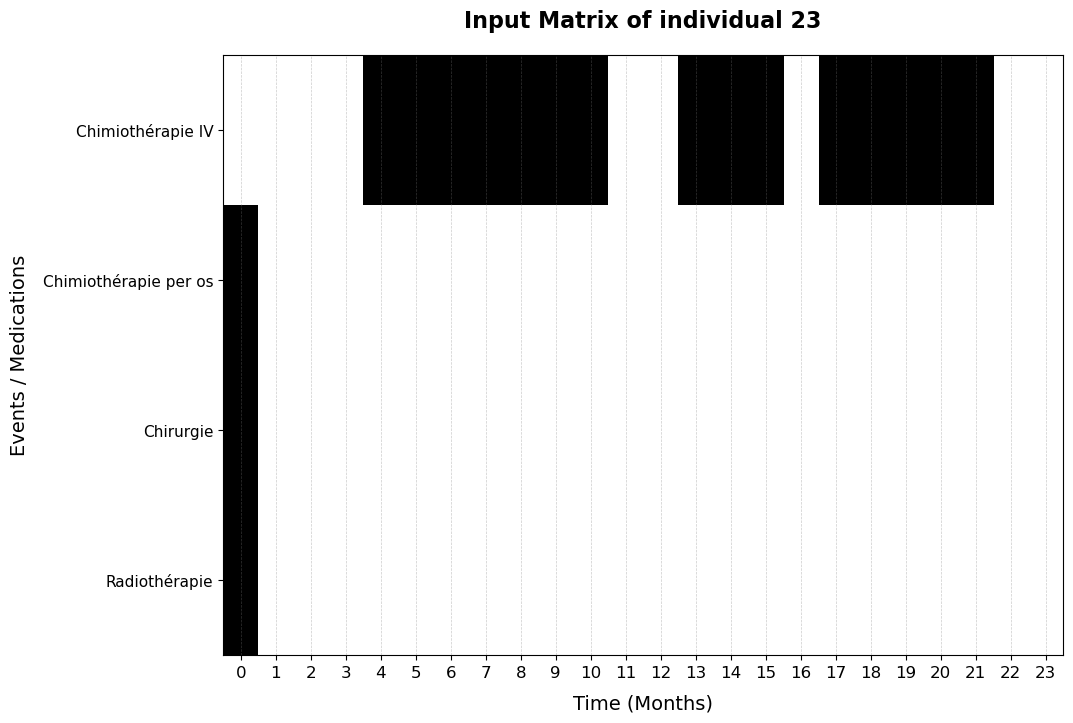

In [22]:
best_rank = 3
best_window = 2

tca.analyzer.model, tca.analyzer.W = models[(best_rank, best_window)]
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit='Months')

Même avec 200 époques, on a une matrice reconstruite qui n'est pas très ressemblante.

Decomposed into 1336 pathways with rank 3 and time window length 2
FIT metric for the entire dataset: 0.1477
success_rate :0.08274692389450278


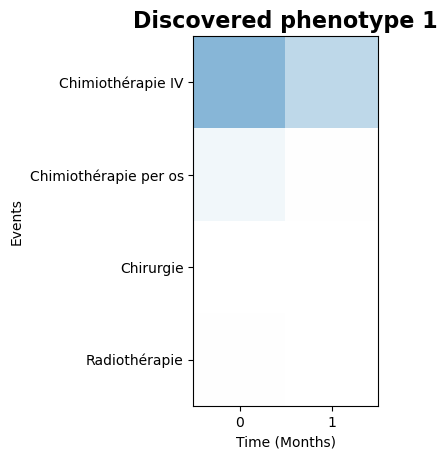

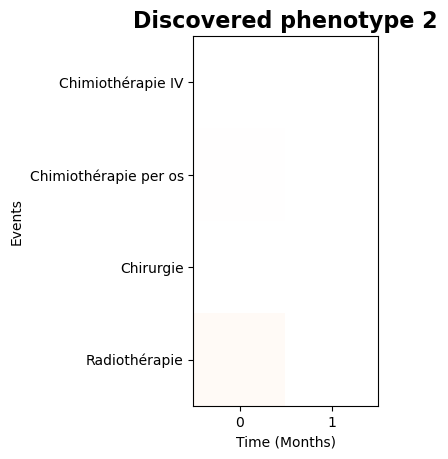

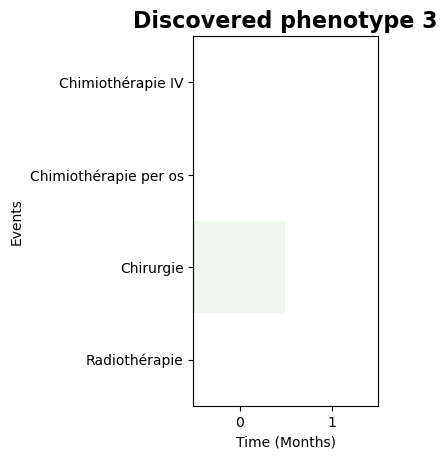

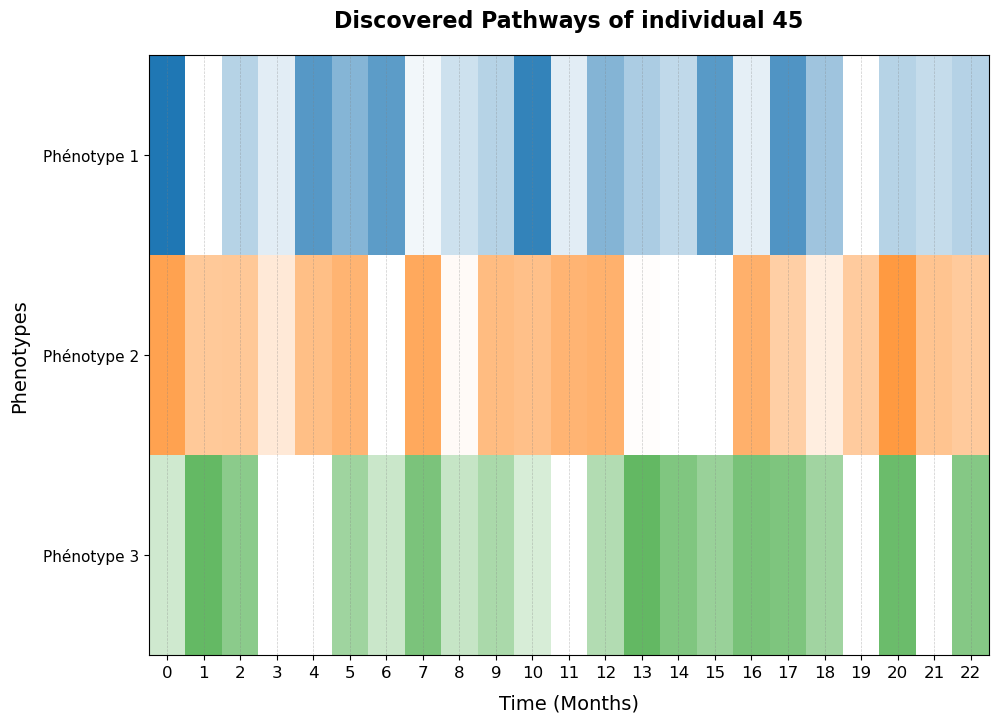

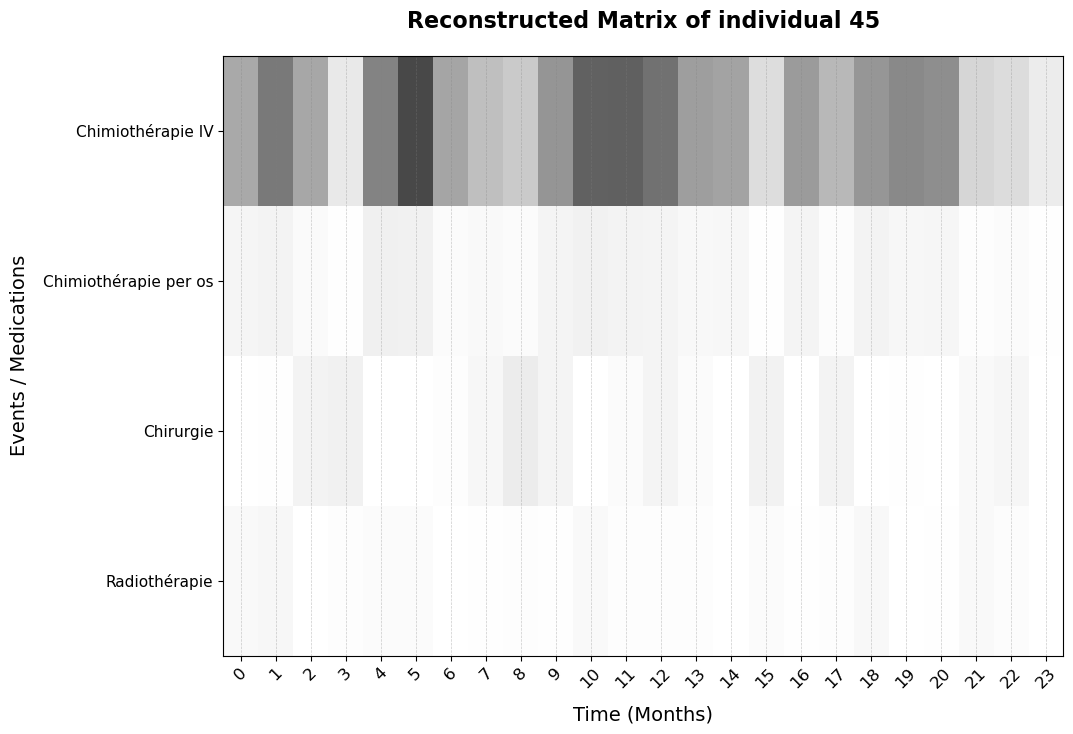

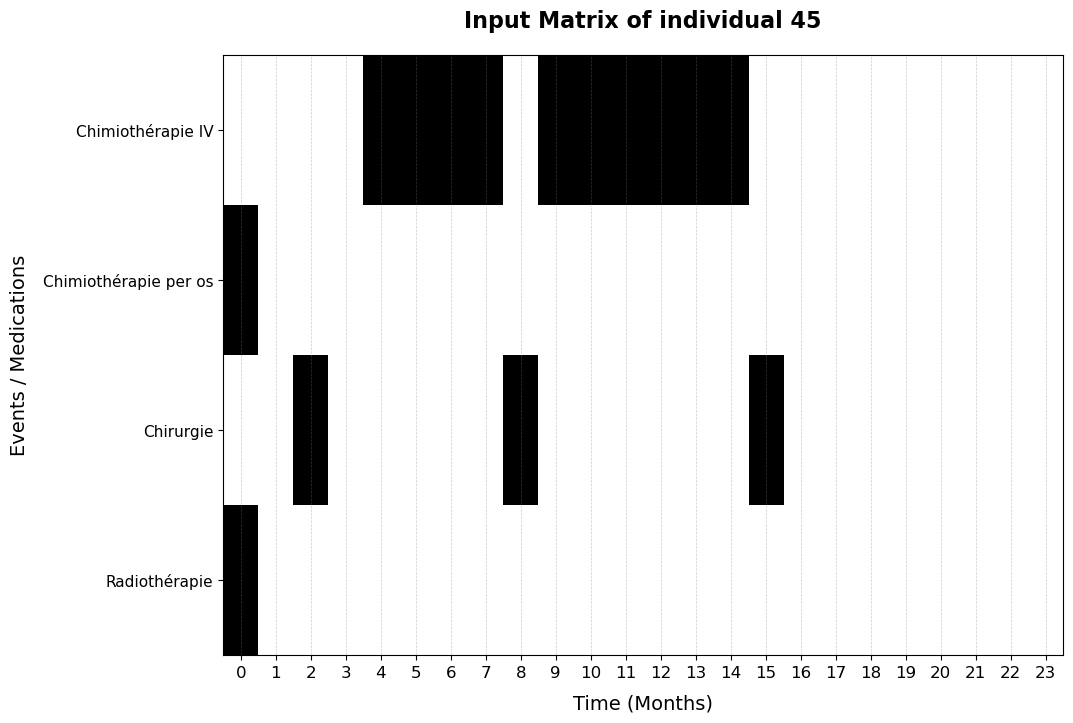

In [24]:
patient_index0 = int(patients_with_all_events[2])
tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index0, time_unit='Months')

## 5. Clustering

### 5.1. Intensités des phénotypes :

In [25]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.292767,0.526049,0.528555,1
1,0.214082,0.469548,0.646128,2
2,0.735602,0.801482,0.370138,3
3,0.457365,0.606858,0.388156,4
4,0.524069,0.631458,0.372790,5


### 5.2. Clustering à partir des intensités :

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


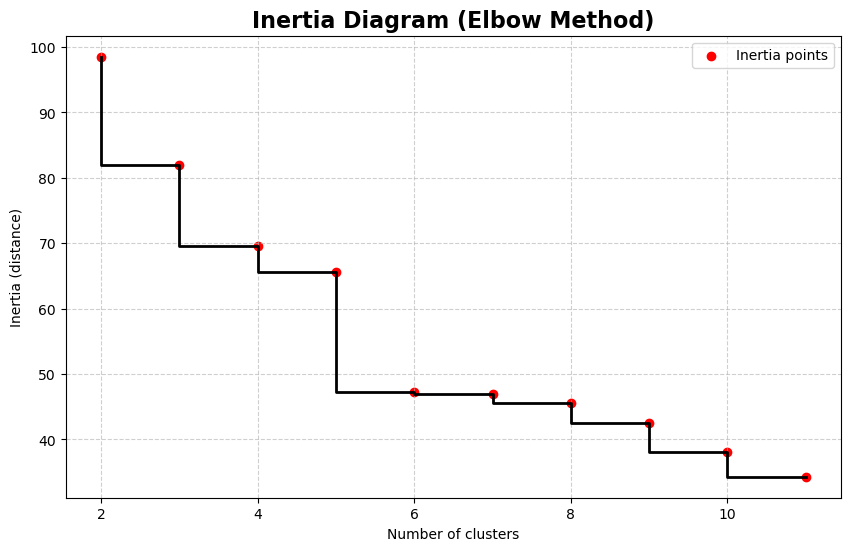

In [26]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

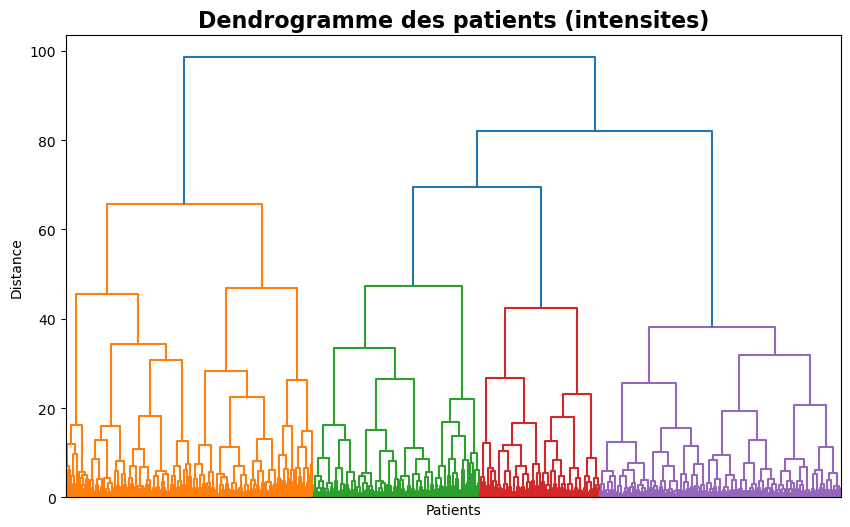

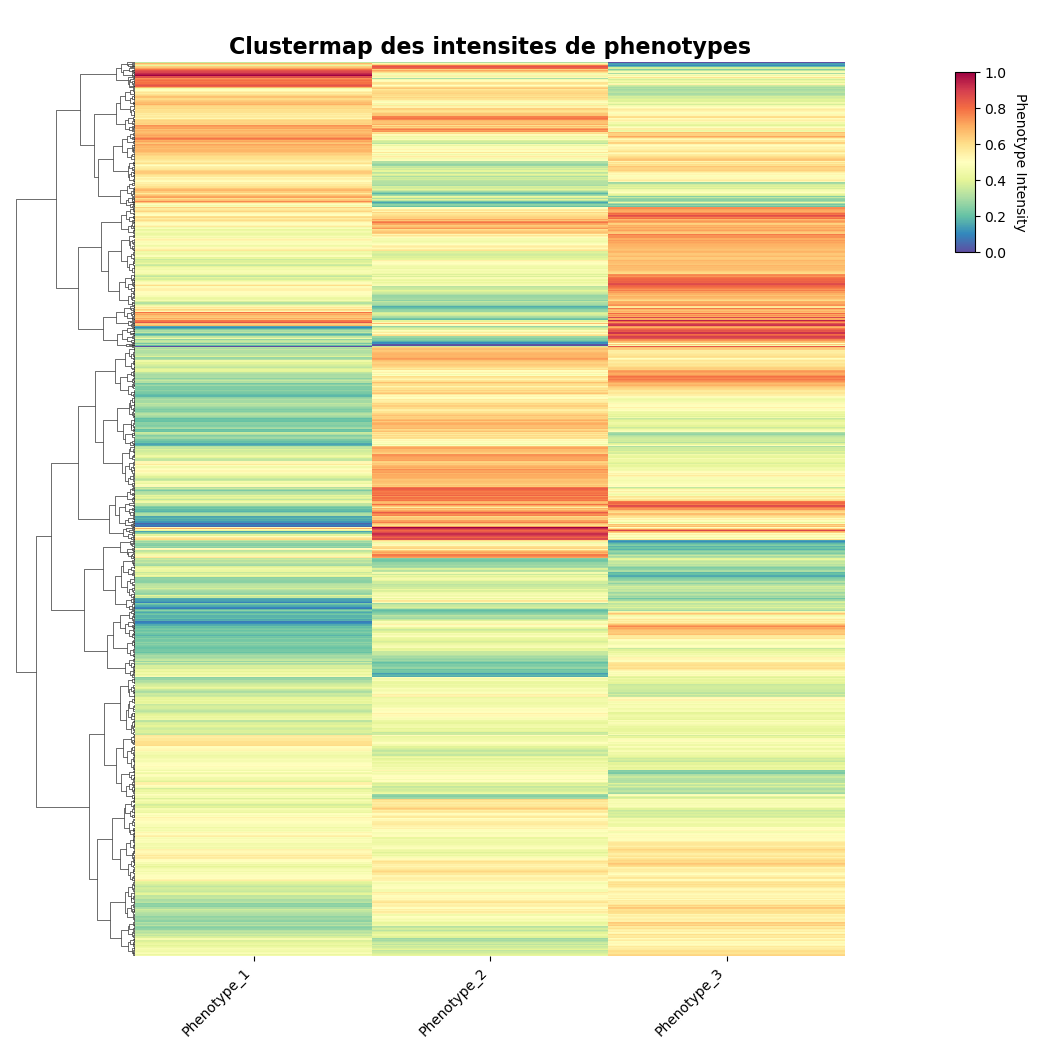

Effectifs par cluster:
1    426
2    288
3    206
4    416
Name: count, dtype: int64


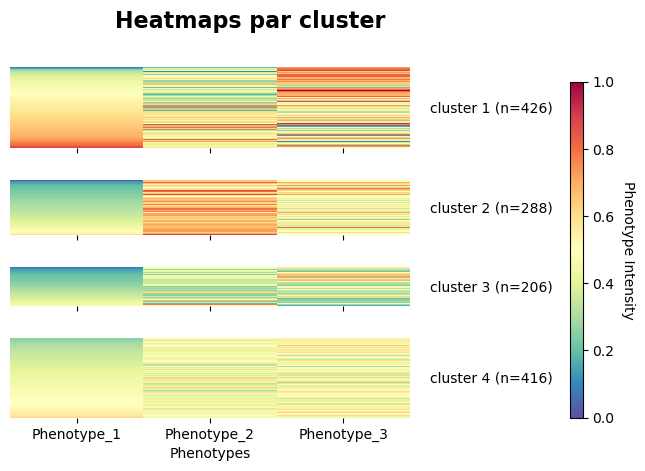

In [36]:
# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')

Premier traitement pour les patients de chaque cluster

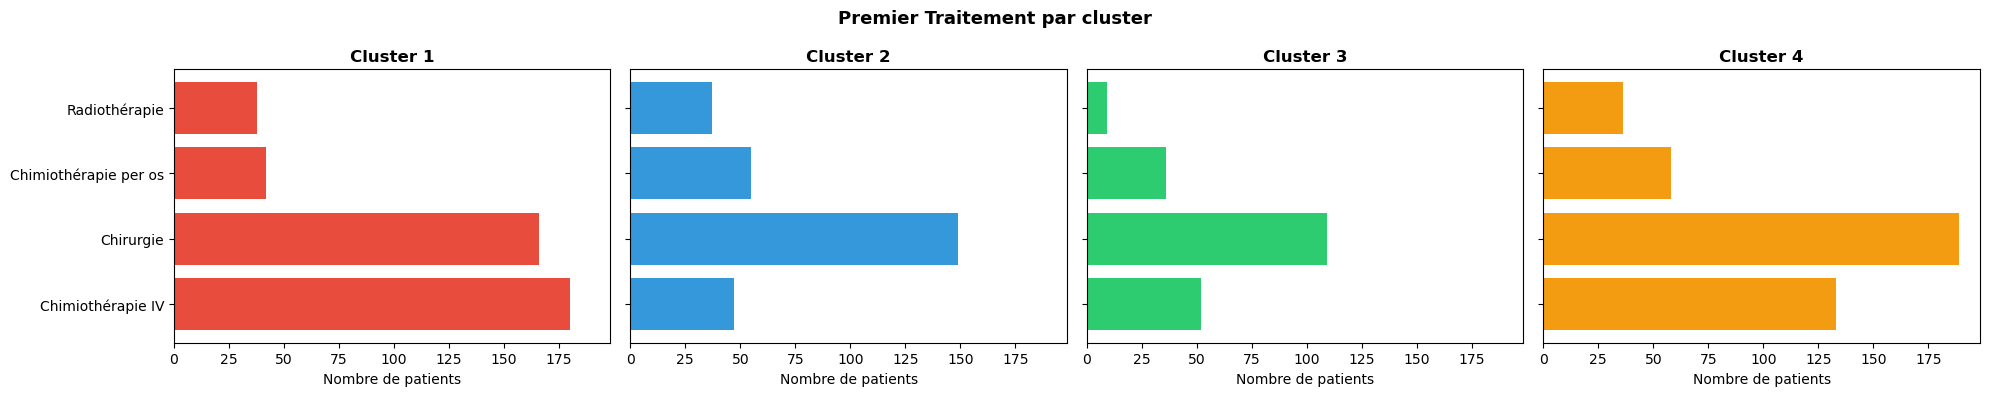

In [41]:
first_trt = timed_event_structure.groupby('ID_PATIENT').apply(
    lambda x: noms_events[x.loc[x['Time'].idxmin(), 'Event']]
)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
n_clusters = len(set(clusters))

fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4), squeeze=False, sharex=True, sharey=True)

for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    counts = first_trt[ids].value_counts()
    ax.barh(counts.index, counts.values, color=colors[c-1])
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Nombre de patients")

fig.suptitle("Premier Traitement par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Durée moyenne sous chaque traitement par cluster

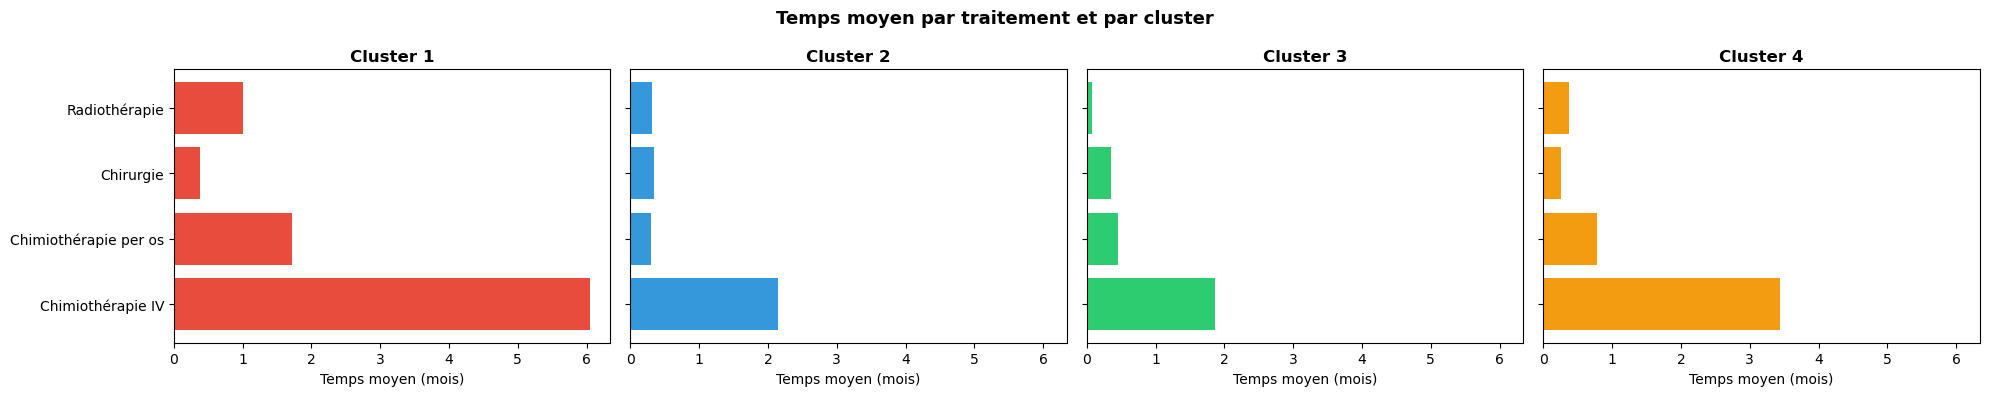

In [45]:
mean_time_trt = timed_event_structure.groupby(['ID_PATIENT', 'Event'])['Time'].mean()
mean_time_trt = mean_time_trt.reset_index()
mean_time_trt['Traitement'] = mean_time_trt['Event'].map(dict(enumerate(noms_events)))
mean_time_per_patient = mean_time_trt.groupby(['ID_PATIENT', 'Traitement'])['Time'].mean().unstack(fill_value=0)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
n_clusters = len(set(clusters))

fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4), squeeze=False, sharex=True, sharey=True)

for ax, c in zip(axes[0], sorted(set(clusters))):
    ids = ph_intensity[np.array(clusters) == c]['ID_PATIENT']
    mean_vals = mean_time_per_patient.loc[mean_time_per_patient.index.isin(ids)].mean()
    ax.barh(mean_vals.index, mean_vals.values, color=colors[c-1])
    ax.set_title(f"Cluster {c}", fontweight='bold')
    ax.set_xlabel("Temps moyen (mois)")

fig.suptitle("Temps moyen par traitement et par cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

On a une légère différence, pour le cluster 1, on est plus souvent en chimio IV et per os que les autres.